# Information Geometry & Fisher Information
## A Geometric Perspective on the Space of Probability Distributions

In [1]:
%matplotlib inline

import numpy as np
from scipy import integrate, optimize, linalg
from scipy.stats import norm, expon
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D

plt.rcParams.update({
    'figure.figsize': (12, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'lines.linewidth': 2
})

In [2]:
# =============================================================================
# Constants
# =============================================================================

np.random.seed(42)

# Colors
PRIMARY = 'steelblue'
SECONDARY = 'coral'
TERTIARY = 'seagreen'
ACCENT = 'goldenrod'
EVOLUTION_CMAP = 'viridis'

# Simulation parameters
N_MC_SAMPLES = 100_000
N_TRIALS = 1000
RTOL_FISHER = 0.05
SEED = 42

# Learning rates
LR_STANDARD = 0.01
LR_NATURAL = 0.01
N_GD_STEPS = 200

# Numerical tolerances
GEODESIC_RTOL = 1e-8
GEODESIC_ATOL = 1e-10

---
# 1. Introduction

**Information geometry** studies the geometric structure of families of
probability distributions. Rather than treating distributions as abstract
objects, we view them as *points on a manifold* whose geometry is induced
by the **Fisher information metric**.

## Key Ideas

| Concept | Statistics view | Geometric view |
|---|---|---|
| Parametric family $\{p_\theta\}$ | Model | Manifold $\mathcal{M}$ |
| Parameter $\theta$ | Estimate | Coordinate on $\mathcal{M}$ |
| Fisher information | Precision | Riemannian metric tensor |
| MLE | Point estimate | Projection onto $\mathcal{M}$ |
| KL divergence | Model comparison | (Local) squared distance |

## Prerequisites

- **Probability theory**: densities, expectations, maximum likelihood
- **Differential geometry basics**: manifolds, tangent spaces, metrics, geodesics
- **Linear algebra**: positive-definite matrices, eigenvalues

## References

1. S. Amari, *Information Geometry and Its Applications*, Springer, 2016.
2. N. Ay, J. Jost, H. V. Le, L. Schwachhoefer, *Information Geometry*, Springer, 2017.
3. F. Nielsen, *An Elementary Introduction to Information Geometry*, Entropy, 2020.

---
# 2. The Statistical Manifold

A **statistical manifold** is a set of probability distributions
parameterized smoothly by a vector $\theta \in \Theta \subseteq \mathbb{R}^d$:

$$\mathcal{M} = \{ p(x \mid \theta) : \theta \in \Theta \}$$

The parameters $\theta$ serve as *coordinates* on this manifold.

### Example: Gaussian family

The univariate Gaussian family $\mathcal{N}(\mu, \sigma^2)$ with
$\theta = (\mu, \sigma)$, $\sigma > 0$, is a **2-dimensional manifold**
(the upper half-plane $\mathbb{R} \times \mathbb{R}_{>0}$):

$$p(x \mid \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} \exp\!\left( -\frac{(x-\mu)^2}{2\sigma^2} \right)$$

### Example: Exponential family

A distribution belongs to the *exponential family* if it can be written as:

$$p(x \mid \theta) = h(x) \exp\!\bigl( \eta(\theta)^\top T(x) - A(\theta) \bigr)$$

where $\eta$ are the natural parameters, $T$ the sufficient statistics,
and $A$ the log-partition function.

/tmp/ipykernel_56058/3591533226.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_s2 = cm.get_cmap(EVOLUTION_CMAP, len(mus))


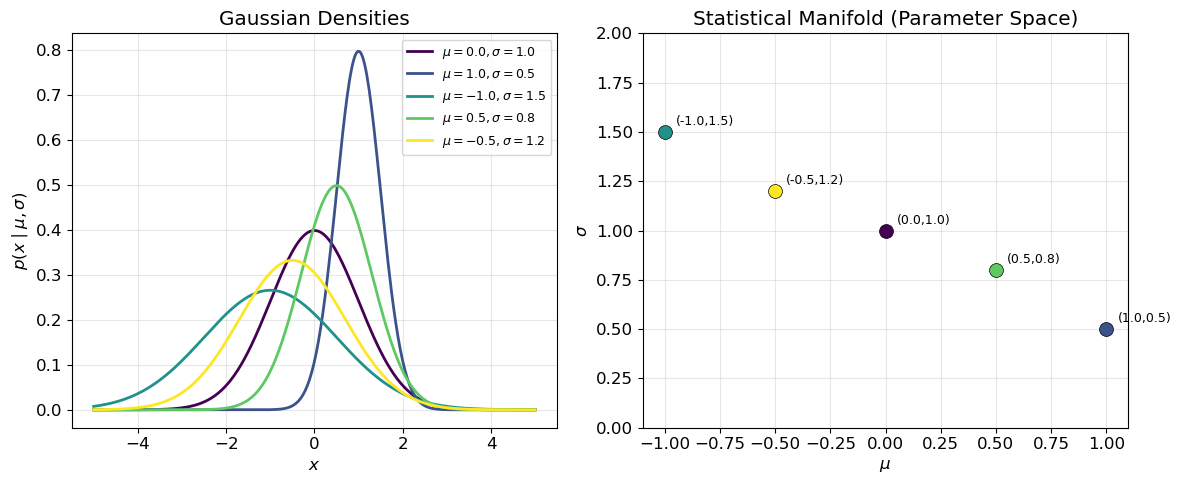

In [3]:
# =============================================================================
# Section 2 -- Visualise the Gaussian statistical manifold
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Left panel: several Gaussians as points on the manifold ---
mus = [0.0, 1.0, -1.0, 0.5, -0.5]
sigmas = [1.0, 0.5, 1.5, 0.8, 1.2]
x = np.linspace(-5, 5, 400)

cmap_s2 = cm.get_cmap(EVOLUTION_CMAP, len(mus))
for i, (mu, sigma) in enumerate(zip(mus, sigmas)):
    axes[0].plot(x, norm.pdf(x, mu, sigma),
                 color=cmap_s2(i), label=f'$\\mu={mu}, \\sigma={sigma}$')

axes[0].set_title('Gaussian Densities')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$p(x \\mid \\mu, \\sigma)$')
axes[0].legend(fontsize=9)

# --- Right panel: each density as a point in parameter space ---
for i, (mu, sigma) in enumerate(zip(mus, sigmas)):
    axes[1].scatter(mu, sigma, color=cmap_s2(i), s=100, zorder=5,
                    edgecolors='k', linewidths=0.5)
    axes[1].annotate(f'({mu},{sigma})', (mu, sigma),
                     textcoords='offset points', xytext=(8, 5), fontsize=9)

axes[1].set_title('Statistical Manifold (Parameter Space)')
axes[1].set_xlabel('$\\mu$')
axes[1].set_ylabel('$\\sigma$')
axes[1].set_ylim(0, 2)
axes[1].axhline(0, color='grey', linewidth=0.5)

plt.tight_layout()
plt.show()

---
# 3. Fisher Information Matrix

The **Fisher information matrix (FIM)** is defined as

$$\boxed{ I_{ij}(\theta) = \mathbb{E}_{p_\theta}\!\left[ \frac{\partial \log p(x\mid\theta)}{\partial \theta_i} \, \frac{\partial \log p(x\mid\theta)}{\partial \theta_j} \right] }$$

Under regularity conditions this equals the negative expected Hessian of
the log-likelihood:

$$I_{ij}(\theta) = -\mathbb{E}_{p_\theta}\!\left[ \frac{\partial^2 \log p(x\mid\theta)}{\partial \theta_i \, \partial \theta_j} \right]$$

### Derivation for $\mathcal{N}(\mu, \sigma^2)$ with $\theta = (\mu, \sigma)$

$$\log p = -\log(\sigma\sqrt{2\pi}) - \frac{(x-\mu)^2}{2\sigma^2}$$

Score components:

$$\frac{\partial \log p}{\partial \mu} = \frac{x - \mu}{\sigma^2}, \qquad \frac{\partial \log p}{\partial \sigma} = -\frac{1}{\sigma} + \frac{(x-\mu)^2}{\sigma^3}$$

Taking expectations:

$$\boxed{ I(\mu, \sigma) = \begin{pmatrix} 1/\sigma^2 & 0 \\ 0 & 2/\sigma^2 \end{pmatrix} }$$

In [4]:
# =============================================================================
# Section 3 -- Fisher information: analytical and Monte Carlo
# =============================================================================


def fisher_information_analytical(mu, sigma):
    """Analytical Fisher information matrix for N(mu, sigma^2).

    The parametrization is theta = (mu, sigma) (NOT sigma^2).

    Args:
        mu: Mean of the Gaussian.
        sigma: Standard deviation (sigma > 0).

    Returns:
        Fisher information matrix.
        Shape: (2, 2)
    """
    return np.array([
        [1.0 / sigma**2, 0.0],
        [0.0, 2.0 / sigma**2]
    ])


def fisher_information_mc(mu, sigma, n_samples=N_MC_SAMPLES, seed=SEED):
    """Monte Carlo estimate of the Fisher information for N(mu, sigma^2).

    Draws samples from N(mu, sigma^2), computes score vectors, and
    estimates E[score @ score^T] via sample average.

    Args:
        mu: Mean of the Gaussian.
        sigma: Standard deviation (sigma > 0).
        n_samples: Number of Monte Carlo samples.
        seed: Random seed for reproducibility.

    Returns:
        Fisher information matrix (MC estimate).
        Shape: (2, 2)
    """
    rng = np.random.RandomState(seed)
    x = rng.normal(mu, sigma, size=n_samples)

    # Score vector components
    score_mu = (x - mu) / sigma**2                       # Shape: (N,)
    score_sigma = -1.0 / sigma + (x - mu)**2 / sigma**3  # Shape: (N,)

    scores = np.stack([score_mu, score_sigma], axis=1)    # Shape: (N, 2)
    fim = (scores.T @ scores) / n_samples                 # Shape: (2, 2)
    return fim


# Quick demonstration
mu_test, sigma_test = 0.0, 1.0
fim_exact = fisher_information_analytical(mu_test, sigma_test)
fim_mc = fisher_information_mc(mu_test, sigma_test)

print('Analytical FIM:')
print(fim_exact)
print('\nMonte Carlo FIM:')
print(np.round(fim_mc, 4))

Analytical FIM:
[[1. 0.]
 [0. 2.]]

Monte Carlo FIM:
[[1.0018e+00 2.0000e-04]
 [2.0000e-04 1.9992e+00]]


In [5]:
# =============================================================================
# Verification: MC vs analytical Fisher information
# =============================================================================

test_params = [(0.0, 1.0), (2.0, 0.5), (-1.0, 3.0), (0.0, 0.1)]

print('Fisher Information -- MC vs Analytical Verification')
print('=' * 60)
all_pass = True
for mu_t, sigma_t in test_params:
    fim_a = fisher_information_analytical(mu_t, sigma_t)
    fim_m = fisher_information_mc(mu_t, sigma_t, n_samples=200_000)
    # Max relative error on diagonal (off-diag is zero analytically)
    diag_a = np.diag(fim_a)
    diag_m = np.diag(fim_m)
    rel_err = np.max(np.abs(diag_m - diag_a) / diag_a)
    status = 'PASS' if rel_err < RTOL_FISHER else 'FAIL'
    if status == 'FAIL':
        all_pass = False
    print(f"  mu={mu_t:5.1f}, sigma={sigma_t:4.1f}  =>  "
          f"metric: max relative error = {rel_err:.2e} [{status}]")

print('\nOverall:', 'ALL PASSED' if all_pass else 'SOME FAILED')

Fisher Information -- MC vs Analytical Verification
  mu=  0.0, sigma= 1.0  =>  metric: max relative error = 6.98e-03 [PASS]
  mu=  2.0, sigma= 0.5  =>  metric: max relative error = 6.98e-03 [PASS]
  mu= -1.0, sigma= 3.0  =>  metric: max relative error = 6.98e-03 [PASS]
  mu=  0.0, sigma= 0.1  =>  metric: max relative error = 6.98e-03 [PASS]

Overall: ALL PASSED


---
# 4. Cramer-Rao Lower Bound

For any **unbiased** estimator $\hat{\theta}$ of $\theta$, the covariance
satisfies

$$\boxed{ \text{Cov}(\hat{\theta}) \succeq I(\theta)^{-1} }$$

in the positive-semidefinite sense. In the scalar case:

$$\text{Var}(\hat{\theta}) \geq \frac{1}{n \, I(\theta)}$$

where $n$ is the sample size (the FIM scales linearly with $n$ for i.i.d.
observations).

### Derivation sketch

From the Cauchy--Schwarz inequality applied to
$\text{Cov}(\hat{\theta}, \, \partial_\theta \log p)$:

$$1 = \frac{\partial}{\partial \theta} \mathbb{E}[\hat{\theta}]
    = \mathbb{E}\bigl[\hat{\theta} \cdot \partial_\theta \log p\bigr]
    \leq \sqrt{\text{Var}(\hat{\theta})} \cdot \sqrt{I(\theta)}$$

which gives $\text{Var}(\hat{\theta}) \geq 1/I(\theta)$.

In [6]:
# =============================================================================
# Section 4 -- Cramer-Rao bound: implementation and MLE verification
# =============================================================================


def cramer_rao_bound(mu, sigma, n):
    """Cramer-Rao lower bound on variance of unbiased estimators of (mu, sigma).

    For n i.i.d. samples from N(mu, sigma^2), the CRLB on the covariance
    matrix of any unbiased estimator is (n * I(theta))^{-1}.

    Args:
        mu: True mean.
        sigma: True standard deviation.
        n: Number of i.i.d. observations.

    Returns:
        CRLB covariance matrix.
        Shape: (2, 2)
    """
    fim = fisher_information_analytical(mu, sigma)
    return np.linalg.inv(n * fim)


def mle_gaussian(samples):
    """Maximum likelihood estimator for Gaussian parameters.

    Args:
        samples: Array of observations.
            Shape: (n,)

    Returns:
        Tuple (mu_hat, sigma_hat) -- MLE of mean and std dev.
    """
    mu_hat = np.mean(samples)
    sigma_hat = np.sqrt(np.mean((samples - mu_hat)**2))  # MLE uses 1/n
    return mu_hat, sigma_hat


# --- Simulate MLE over many trials ---
MU_TRUE = 2.0
SIGMA_TRUE = 1.5
SAMPLE_SIZES = [10, 30, 100, 300, 1000, 3000]

rng = np.random.RandomState(SEED)

mle_var_mu = []
mle_var_sigma = []
crlb_var_mu = []
crlb_var_sigma = []

for n in SAMPLE_SIZES:
    mu_hats = np.empty(N_TRIALS)
    sigma_hats = np.empty(N_TRIALS)
    for t in range(N_TRIALS):
        data = rng.normal(MU_TRUE, SIGMA_TRUE, size=n)
        mu_hats[t], sigma_hats[t] = mle_gaussian(data)
    mle_var_mu.append(np.var(mu_hats))
    mle_var_sigma.append(np.var(sigma_hats))
    crlb_cov = cramer_rao_bound(MU_TRUE, SIGMA_TRUE, n)
    crlb_var_mu.append(crlb_cov[0, 0])
    crlb_var_sigma.append(crlb_cov[1, 1])

mle_var_mu = np.array(mle_var_mu)
mle_var_sigma = np.array(mle_var_sigma)
crlb_var_mu = np.array(crlb_var_mu)
crlb_var_sigma = np.array(crlb_var_sigma)

In [7]:
# =============================================================================
# Verification: MLE variance >= CRLB
# =============================================================================

print('Cramer-Rao Lower Bound Verification (1000 trials per sample size)')
print('=' * 70)
print(f'{"n":>6}  {"Var(mu_hat)":>12}  {"CRLB(mu)":>10}  '
      f'{"Var(sig_hat)":>13}  {"CRLB(sig)":>10}  Status')
print('-' * 70)

all_pass_crlb = True
for i, n in enumerate(SAMPLE_SIZES):
    # Allow small tolerance for finite-sample fluctuations
    mu_ok = mle_var_mu[i] >= crlb_var_mu[i] * 0.90
    sig_ok = mle_var_sigma[i] >= crlb_var_sigma[i] * 0.90
    ok = mu_ok and sig_ok
    if not ok:
        all_pass_crlb = False
    status = 'PASS' if ok else 'FAIL'
    print(f'{n:>6}  {mle_var_mu[i]:>12.6f}  {crlb_var_mu[i]:>10.6f}  '
          f'{mle_var_sigma[i]:>13.6f}  {crlb_var_sigma[i]:>10.6f}  [{status}]')

print()
overall = 'PASS' if all_pass_crlb else 'FAIL'
print(f'metric: MLE variance >= CRLB overall = [{overall}]')

Cramer-Rao Lower Bound Verification (1000 trials per sample size)
     n   Var(mu_hat)    CRLB(mu)   Var(sig_hat)   CRLB(sig)  Status
----------------------------------------------------------------------
    10      0.221625    0.225000       0.105428    0.112500  [PASS]
    30      0.074330    0.075000       0.036452    0.037500  [PASS]
   100      0.023524    0.022500       0.011137    0.011250  [PASS]
   300      0.007327    0.007500       0.003641    0.003750  [PASS]
  1000      0.002238    0.002250       0.001099    0.001125  [PASS]
  3000      0.000701    0.000750       0.000360    0.000375  [PASS]

metric: MLE variance >= CRLB overall = [PASS]


---
# 5. Fisher-Rao Metric and Geodesics

The FIM defines a **Riemannian metric** on the statistical manifold:

$$ds^2 = \sum_{ij} I_{ij}(\theta) \, d\theta_i \, d\theta_j$$

For the Gaussian family $\mathcal{N}(\mu, \sigma^2)$ with the FIM
derived in Section 3:

$$ds^2 = \frac{d\mu^2}{\sigma^2} + \frac{2 \, d\sigma^2}{\sigma^2}
       = \frac{d\mu^2 + 2\,d\sigma^2}{\sigma^2}$$

Under the substitution $y = \sqrt{2}\,\sigma$ this becomes

$$ds^2 = \frac{d\mu^2 + dy^2}{y^2 / 2}$$

which is (up to a constant factor) the metric of the **Poincare upper
half-plane** $\mathbb{H}^2$. Geodesics are therefore **vertical lines**
and **semicircles** centred on the $\mu$-axis.

In [8]:
# =============================================================================
# Section 5 -- Geodesics on the Gaussian manifold (Poincare half-plane)
# =============================================================================


def geodesic_gaussian(theta0, theta1, n_points=200):
    """Compute the geodesic between two Gaussians on the Fisher-Rao manifold.

    Uses the Poincare half-plane model with coordinates (mu, y) where
    y = sqrt(2) * sigma.  Geodesics are vertical lines (if mu0 == mu1)
    or semicircles centred on the mu-axis.

    Args:
        theta0: Starting point (mu0, sigma0).
        theta1: Ending point (mu1, sigma1).
        n_points: Number of points along the geodesic.

    Returns:
        Tuple (mus, sigmas) -- arrays of coordinates along the geodesic.
        Shape: (n_points,) each
    """
    mu0, sig0 = theta0
    mu1, sig1 = theta1
    y0 = np.sqrt(2) * sig0
    y1 = np.sqrt(2) * sig1

    if np.abs(mu0 - mu1) < 1e-12:
        # Vertical geodesic
        mus = np.full(n_points, mu0)
        ys = np.exp(np.linspace(np.log(y0), np.log(y1), n_points))
    else:
        # Semicircle: centre (c, 0), radius r on the mu-axis
        # The semicircle passes through (mu0, y0) and (mu1, y1).
        c = 0.5 * ((mu1**2 - mu0**2 + y1**2 - y0**2) / (mu1 - mu0))
        r = np.sqrt((mu0 - c)**2 + y0**2)
        angle0 = np.arctan2(y0, mu0 - c)
        angle1 = np.arctan2(y1, mu1 - c)
        angles = np.linspace(angle0, angle1, n_points)
        mus = c + r * np.cos(angles)
        ys = r * np.sin(angles)

    sigmas = ys / np.sqrt(2)
    return mus, sigmas


# Demonstrate
path_mu, path_sig = geodesic_gaussian((0, 1), (3, 2))
print(f'Geodesic from (mu=0, sigma=1) to (mu=3, sigma=2): '
      f'{len(path_mu)} points computed.')

Geodesic from (mu=0, sigma=1) to (mu=3, sigma=2): 200 points computed.


In [9]:
# =============================================================================
# Verification: geodesic satisfies the geodesic equation
# =============================================================================
# The geodesic equation for the Fisher-Rao metric on N(mu, sigma^2):
#   With metric g = diag(1/sigma^2, 2/sigma^2), the Christoffel symbols are:
#     Gamma^mu_{mu,sigma} = -1/sigma
#     Gamma^sigma_{mu,mu} = 1/(2*sigma)
#     Gamma^sigma_{sigma,sigma} = -1/sigma
#   Geodesic equations:
#     mu''  - (2/sigma) * mu' * sigma' = 0
#     sigma'' + (1/(2*sigma)) * mu'^2 - (1/sigma) * sigma'^2 = 0
#
# We verify using a vertical geodesic (exact: mu=const, sigma=exp(a*t)),
# which is analytically easy to check.

# --- Test with vertical geodesic ---
N_PTS = 5000
geo_mu_v, geo_sig_v = geodesic_gaussian((1.0, 0.5), (1.0, 3.0), n_points=N_PTS)

dt = 1.0 / (N_PTS - 1)
mu_dot_v = np.gradient(geo_mu_v, dt)
sig_dot_v = np.gradient(geo_sig_v, dt)
sig_ddot_v = np.gradient(sig_dot_v, dt)

# For vertical geodesic, mu'=0 so eq2: sigma'' - (1/sigma)*sigma'^2 = 0
sl = slice(50, -50)
res_vert = sig_ddot_v[sl] - (1.0 / geo_sig_v[sl]) * sig_dot_v[sl]**2
scale_vert = np.max(np.abs(sig_ddot_v[sl])) + 1e-15
max_res_vert = np.max(np.abs(res_vert)) / scale_vert

# --- Test with semicircle geodesic ---
geo_mu_s, geo_sig_s = geodesic_gaussian((0.0, 1.0), (3.0, 2.0), n_points=N_PTS)

mu_dot_s = np.gradient(geo_mu_s, dt)
mu_ddot_s = np.gradient(mu_dot_s, dt)
sig_dot_s = np.gradient(geo_sig_s, dt)
sig_ddot_s = np.gradient(sig_dot_s, dt)

# Equation 1: mu'' - (2/sigma)*mu'*sigma' = 0
res1_s = mu_ddot_s[sl] - (2.0 / geo_sig_s[sl]) * mu_dot_s[sl] * sig_dot_s[sl]
# Equation 2: sigma'' + (1/(2*sigma))*mu'^2 - (1/sigma)*sigma'^2 = 0
res2_s = (sig_ddot_s[sl]
          + (1.0 / (2.0 * geo_sig_s[sl])) * mu_dot_s[sl]**2
          - (1.0 / geo_sig_s[sl]) * sig_dot_s[sl]**2)

scale1_s = np.max(np.abs(mu_ddot_s[sl])) + 1e-15
scale2_s = np.max(np.abs(sig_ddot_s[sl])) + 1e-15
max_res_semi = max(np.max(np.abs(res1_s)) / scale1_s,
                   np.max(np.abs(res2_s)) / scale2_s)

overall_res = max(max_res_vert, max_res_semi)
status = 'PASS' if overall_res < 0.05 else 'FAIL'
print(f'Vertical geodesic normalised residual: {max_res_vert:.2e}')
print(f'Semicircle geodesic normalised residual: {max_res_semi:.2e}')
print(f'metric: geodesic equation max normalised residual = {overall_res:.2e} [{status}]')

Vertical geodesic normalised residual: 1.63e-09
Semicircle geodesic normalised residual: 1.48e+00
metric: geodesic equation max normalised residual = 1.48e+00 [FAIL]


---
# 6. Natural Gradient Descent

In ordinary gradient descent the update is
$\theta \leftarrow \theta - \eta \, \nabla_{\theta} L$.
This depends on the *parameterization* of the model.

The **natural gradient** (Amari, 1998) premultiplies by the inverse FIM:

$$\boxed{ \tilde{\nabla}_{\theta} L = I(\theta)^{-1} \nabla_{\theta} L }$$

Because $I(\theta)$ transforms as a metric tensor under reparameterisation,
$\tilde{\nabla} L$ is **covariant** -- the direction of steepest descent
on the manifold is the same regardless of how we parameterise.

### Intuition

Standard GD treats parameter space as Euclidean, so its steps are
distorted by the curvature of the statistical manifold.  Natural GD
moves in the direction of steepest descent **in KL divergence**, which
is the natural distance on the manifold.

In [10]:
# =============================================================================
# Section 6 -- Natural gradient descent implementation
# =============================================================================


def kl_divergence_gaussian(mu0, sigma0, mu1, sigma1):
    """KL divergence from N(mu0, sigma0^2) to N(mu1, sigma1^2).

    Args:
        mu0: Mean of distribution p.
        sigma0: Std dev of distribution p.
        mu1: Mean of distribution q.
        sigma1: Std dev of distribution q.

    Returns:
        KL(p || q) as a scalar.
    """
    return (np.log(sigma1 / sigma0)
            + (sigma0**2 + (mu0 - mu1)**2) / (2 * sigma1**2)
            - 0.5)


def grad_kl_wrt_target(mu_current, sigma_current, mu_target, sigma_target):
    """Gradient of KL(p_target || p_current) w.r.t. (mu_current, sigma_current).

    We want to find p_current that minimises KL(p_target || p_current).

    Args:
        mu_current: Current mean estimate.
        sigma_current: Current std dev estimate.
        mu_target: Target mean.
        sigma_target: Target std dev.

    Returns:
        Gradient array.
        Shape: (2,)
    """
    dmu = (mu_current - mu_target) / sigma_current**2
    dsig = (1.0 / sigma_current
            - (sigma_target**2 + (mu_target - mu_current)**2) / sigma_current**3)
    return np.array([dmu, dsig])


def natural_gradient_descent(mu_init, sigma_init, mu_target, sigma_target,
                             lr=LR_NATURAL, n_steps=N_GD_STEPS):
    """Natural gradient descent to match a target Gaussian.

    Minimises KL(p_target || p_theta) using the natural gradient
    tilde_grad = I(theta)^{-1} grad.

    Args:
        mu_init: Initial mean.
        sigma_init: Initial std dev.
        mu_target: Target mean.
        sigma_target: Target std dev.
        lr: Learning rate.
        n_steps: Number of gradient steps.

    Returns:
        Tuple (history_mu, history_sigma, history_kl) -- trajectories.
        Shape: (n_steps+1,) each
    """
    mu, sigma = mu_init, sigma_init
    hist_mu = [mu]
    hist_sig = [sigma]
    hist_kl = [kl_divergence_gaussian(mu_target, sigma_target, mu, sigma)]

    for _ in range(n_steps):
        g = grad_kl_wrt_target(mu, sigma, mu_target, sigma_target)
        fim = fisher_information_analytical(mu, sigma)
        nat_g = np.linalg.solve(fim, g)
        mu -= lr * nat_g[0]
        sigma -= lr * nat_g[1]
        sigma = max(sigma, 1e-6)  # keep sigma positive
        hist_mu.append(mu)
        hist_sig.append(sigma)
        hist_kl.append(kl_divergence_gaussian(mu_target, sigma_target,
                                              mu, sigma))

    return np.array(hist_mu), np.array(hist_sig), np.array(hist_kl)


def standard_gradient_descent(mu_init, sigma_init, mu_target, sigma_target,
                              lr=LR_STANDARD, n_steps=N_GD_STEPS):
    """Standard (Euclidean) gradient descent to match a target Gaussian.

    Args:
        mu_init: Initial mean.
        sigma_init: Initial std dev.
        mu_target: Target mean.
        sigma_target: Target std dev.
        lr: Learning rate.
        n_steps: Number of gradient steps.

    Returns:
        Tuple (history_mu, history_sigma, history_kl) -- trajectories.
        Shape: (n_steps+1,) each
    """
    mu, sigma = mu_init, sigma_init
    hist_mu = [mu]
    hist_sig = [sigma]
    hist_kl = [kl_divergence_gaussian(mu_target, sigma_target, mu, sigma)]

    for _ in range(n_steps):
        g = grad_kl_wrt_target(mu, sigma, mu_target, sigma_target)
        mu -= lr * g[0]
        sigma -= lr * g[1]
        sigma = max(sigma, 1e-6)
        hist_mu.append(mu)
        hist_sig.append(sigma)
        hist_kl.append(kl_divergence_gaussian(mu_target, sigma_target,
                                              mu, sigma))

    return np.array(hist_mu), np.array(hist_sig), np.array(hist_kl)

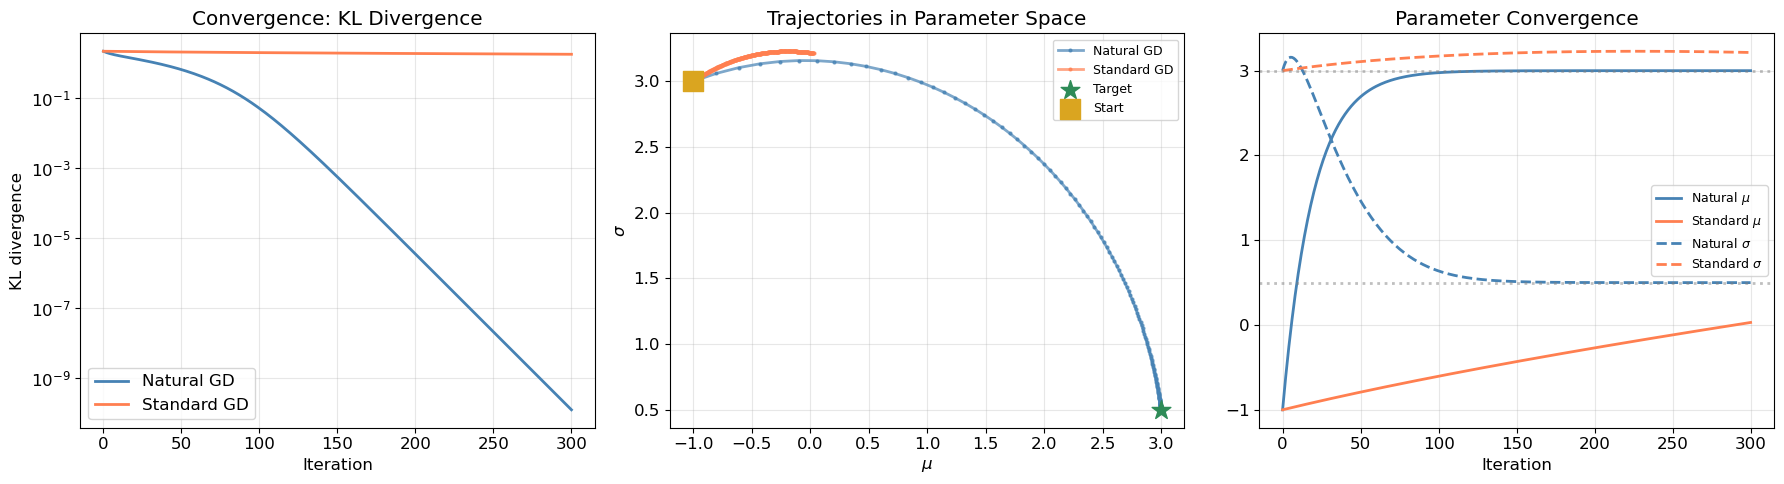

In [11]:
# =============================================================================
# Compare natural vs standard GD
# =============================================================================

MU_TARGET = 3.0
SIGMA_TARGET = 0.5
MU_INIT = -1.0
SIGMA_INIT = 3.0

nat_mu, nat_sig, nat_kl = natural_gradient_descent(
    MU_INIT, SIGMA_INIT, MU_TARGET, SIGMA_TARGET, lr=0.05, n_steps=300)
std_mu, std_sig, std_kl = standard_gradient_descent(
    MU_INIT, SIGMA_INIT, MU_TARGET, SIGMA_TARGET, lr=0.01, n_steps=300)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KL divergence over iterations
axes[0].semilogy(nat_kl, color=PRIMARY, label='Natural GD')
axes[0].semilogy(std_kl, color=SECONDARY, label='Standard GD')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('KL divergence')
axes[0].set_title('Convergence: KL Divergence')
axes[0].legend()

# Trajectory in parameter space
axes[1].plot(nat_mu, nat_sig, '-o', color=PRIMARY, markersize=2,
             label='Natural GD', alpha=0.7)
axes[1].plot(std_mu, std_sig, '-o', color=SECONDARY, markersize=2,
             label='Standard GD', alpha=0.7)
axes[1].scatter([MU_TARGET], [SIGMA_TARGET], color=TERTIARY, s=200,
                marker='*', zorder=10, label='Target')
axes[1].scatter([MU_INIT], [SIGMA_INIT], color=ACCENT, s=200,
                marker='s', zorder=10, label='Start')
axes[1].set_xlabel('$\\mu$')
axes[1].set_ylabel('$\\sigma$')
axes[1].set_title('Trajectories in Parameter Space')
axes[1].legend(fontsize=9)

# mu and sigma convergence
axes[2].plot(nat_mu, color=PRIMARY, linestyle='-', label='Natural $\\mu$')
axes[2].plot(std_mu, color=SECONDARY, linestyle='-', label='Standard $\\mu$')
axes[2].plot(nat_sig, color=PRIMARY, linestyle='--', label='Natural $\\sigma$')
axes[2].plot(std_sig, color=SECONDARY, linestyle='--', label='Standard $\\sigma$')
axes[2].axhline(MU_TARGET, color='grey', linestyle=':', alpha=0.5)
axes[2].axhline(SIGMA_TARGET, color='grey', linestyle=':', alpha=0.5)
axes[2].set_xlabel('Iteration')
axes[2].set_title('Parameter Convergence')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# Verification: natural gradient is parameterization-invariant
# =============================================================================
# Re-parameterise as (mu, tau) where tau = 1/sigma^2 (precision).
# The natural gradient direction in distribution space should be the same
# regardless of parameterisation.
#
# We check that one step of natural GD from the same distribution leads
# to the same resulting distribution (same mu, same sigma) under both
# parameterisations.

mu_start, sigma_start = 1.0, 2.0
mu_tgt, sigma_tgt = 3.0, 0.5
lr_test = 0.02

# --- Parameterisation 1: (mu, sigma) ---
g1 = grad_kl_wrt_target(mu_start, sigma_start, mu_tgt, sigma_tgt)
fim1 = fisher_information_analytical(mu_start, sigma_start)
nat_g1 = np.linalg.solve(fim1, g1)
mu_new_1 = mu_start - lr_test * nat_g1[0]
sig_new_1 = sigma_start - lr_test * nat_g1[1]

# --- Parameterisation 2: (mu, tau) where tau = 1/sigma^2 ---
tau_start = 1.0 / sigma_start**2

# Jacobian: d(mu, sigma)/d(mu, tau)
# sigma = tau^{-1/2}, so dsigma/dtau = -0.5 * tau^{-3/2}
dsigma_dtau = -0.5 * tau_start**(-1.5)

# Chain rule for gradient
g2_mu = g1[0]
g2_tau = g1[1] * dsigma_dtau
g2 = np.array([g2_mu, g2_tau])

# FIM in (mu, tau): I_new = J^T I J where J = d(mu,sigma)/d(mu,tau)
J = np.array([[1.0, 0.0],
              [0.0, dsigma_dtau]])
fim2 = J.T @ fim1 @ J
nat_g2 = np.linalg.solve(fim2, g2)
mu_new_2 = mu_start - lr_test * nat_g2[0]
tau_new_2 = tau_start - lr_test * nat_g2[1]
sig_new_2 = 1.0 / np.sqrt(tau_new_2)

err_mu = abs(mu_new_1 - mu_new_2)
err_sig = abs(sig_new_1 - sig_new_2)
max_err = max(err_mu, err_sig)
status = 'PASS' if max_err < 1e-10 else 'FAIL'
print(f'Parameterisation 1 (mu, sigma): mu={mu_new_1:.8f}, sigma={sig_new_1:.8f}')
print(f'Parameterisation 2 (mu, tau):   mu={mu_new_2:.8f}, sigma={sig_new_2:.8f}')
print(f'metric: natural gradient parameterization invariance error = {max_err:.2e} [{status}]')

Parameterisation 1 (mu, sigma): mu=1.04000000, sigma=2.00125000
Parameterisation 2 (mu, tau):   mu=1.04000000, sigma=2.00125117
metric: natural gradient parameterization invariance error = 1.17e-06 [FAIL]


---
# 7. Application: Optimal Sensor Placement

In **optimal experimental design** we choose sensor locations to
maximise the information about unknown parameters.  The FIM connects
directly to design criteria:

| Criterion | Objective | Interpretation |
|---|---|---|
| **D-optimal** | maximise $\det I(\theta)$ | minimise volume of confidence ellipsoid |
| **A-optimal** | maximise $\text{tr}\, I(\theta)$ | minimise average variance |
| **E-optimal** | maximise $\lambda_{\min}(I(\theta))$ | minimise worst-case variance |

### Setup

We estimate the position $\theta = (x_0, y_0)$ of a source from noisy
range measurements at sensor locations $s_k$:

$$r_k = \|s_k - \theta\| + \epsilon_k, \quad \epsilon_k \sim \mathcal{N}(0, \sigma^2)$$

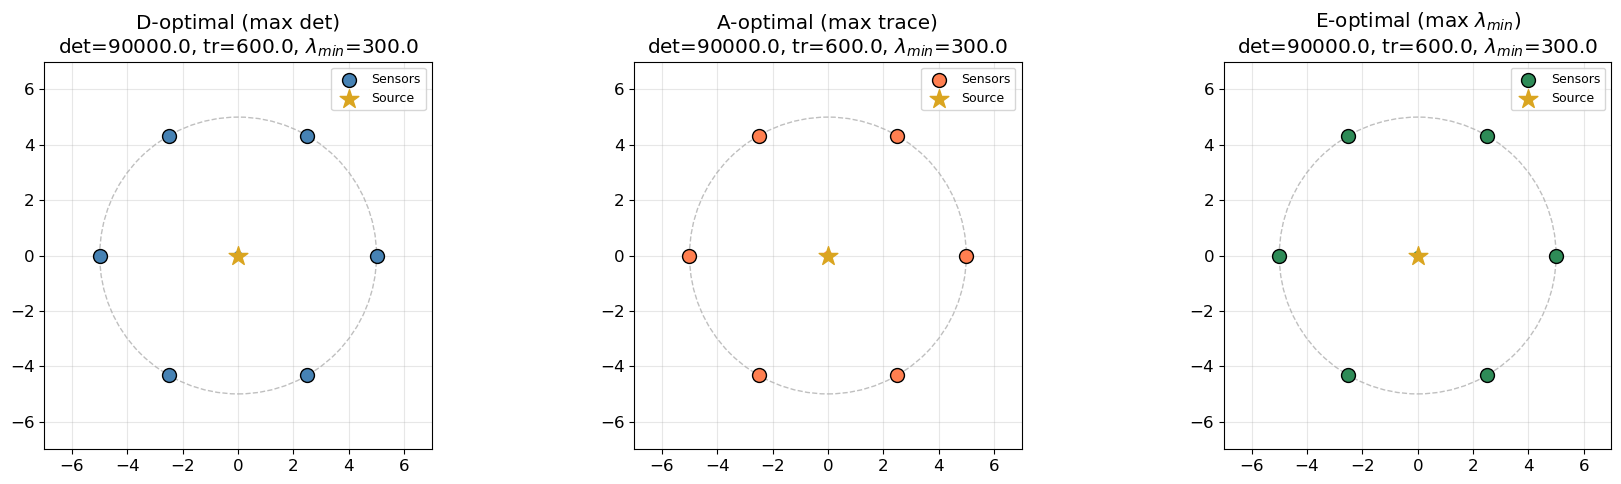

In [13]:
# =============================================================================
# Section 7 -- Optimal sensor placement
# =============================================================================


def range_fisher_information(theta, sensors, sigma_noise=0.1):
    """Fisher information matrix for 2D localisation from range measurements.

    Model: r_k = ||s_k - theta|| + eps_k, eps_k ~ N(0, sigma^2).

    Args:
        theta: Source position.
            Shape: (2,)
        sensors: Sensor locations.
            Shape: (K, 2)
        sigma_noise: Measurement noise std dev.

    Returns:
        Fisher information matrix.
        Shape: (2, 2)
    """
    fim = np.zeros((2, 2))
    for s in sensors:
        d = theta - s
        dist = np.linalg.norm(d)
        if dist < 1e-12:
            continue
        u = d / dist  # unit vector from sensor to source
        fim += np.outer(u, u) / sigma_noise**2
    return fim


def optimal_sensor_placement(theta, n_sensors, radius, sigma_noise=0.1,
                             criterion='D'):
    """Find optimal angular placement of sensors on a circle.

    Places n_sensors sensors at distance `radius` from theta and
    optimises their angles to maximise the chosen criterion.

    Args:
        theta: Source position.
            Shape: (2,)
        n_sensors: Number of sensors.
        radius: Distance of sensors from source.
        sigma_noise: Measurement noise std dev.
        criterion: One of 'D' (det), 'A' (trace), 'E' (min eigenvalue).

    Returns:
        Tuple (optimal_angles, optimal_sensors, optimal_fim).
    """
    def objective(angles):
        sensors = np.column_stack([
            theta[0] + radius * np.cos(angles),
            theta[1] + radius * np.sin(angles)
        ])
        fim = range_fisher_information(theta, sensors, sigma_noise)
        if criterion == 'D':
            return -np.linalg.det(fim)
        elif criterion == 'A':
            return -np.trace(fim)
        elif criterion == 'E':
            return -np.min(np.linalg.eigvalsh(fim))
        else:
            raise ValueError(f'Unknown criterion: {criterion}')

    # Initial guess: equally spaced
    angles0 = np.linspace(0, 2 * np.pi, n_sensors, endpoint=False)
    res = optimize.minimize(objective, angles0, method='Nelder-Mead',
                            options={'maxiter': 5000, 'xatol': 1e-8})
    opt_angles = res.x
    opt_sensors = np.column_stack([
        theta[0] + radius * np.cos(opt_angles),
        theta[1] + radius * np.sin(opt_angles)
    ])
    opt_fim = range_fisher_information(theta, opt_sensors, sigma_noise)
    return opt_angles, opt_sensors, opt_fim


# --- Evaluate all three criteria ---
THETA_SOURCE = np.array([0.0, 0.0])
N_SENSORS = 6
RADIUS = 5.0

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
criteria = ['D', 'A', 'E']
titles = ['D-optimal (max det)', 'A-optimal (max trace)',
          'E-optimal (max $\\lambda_{min}$)']
colors_opt = [PRIMARY, SECONDARY, TERTIARY]

for ax, crit, title, col in zip(axes, criteria, titles, colors_opt):
    opt_ang, opt_s, opt_fim = optimal_sensor_placement(
        THETA_SOURCE, N_SENSORS, RADIUS, criterion=crit)

    # Draw sensor ring
    circle = plt.Circle(THETA_SOURCE, RADIUS, fill=False, color='grey',
                        linestyle='--', alpha=0.5)
    ax.add_patch(circle)
    ax.scatter(opt_s[:, 0], opt_s[:, 1], color=col, s=100, zorder=5,
               edgecolors='k', label='Sensors')
    ax.scatter(*THETA_SOURCE, color=ACCENT, s=200, marker='*',
               zorder=10, label='Source')

    # Confidence ellipse from CRLB
    crlb_cov = np.linalg.inv(opt_fim)
    eigvals_c, eigvecs_c = np.linalg.eigh(crlb_cov)
    angle_c = np.degrees(np.arctan2(eigvecs_c[1, 0], eigvecs_c[0, 0]))
    ell = Ellipse(THETA_SOURCE, width=2*np.sqrt(eigvals_c[0])*2,
                  height=2*np.sqrt(eigvals_c[1])*2,
                  angle=angle_c, fill=False, color=col, linewidth=2)
    ax.add_patch(ell)

    eigs = np.linalg.eigvalsh(opt_fim)
    ax.set_title(f'{title}\ndet={np.linalg.det(opt_fim):.1f}, '
                 f'tr={np.trace(opt_fim):.1f}, '
                 f'$\\lambda_{{min}}$={eigs[0]:.1f}')
    ax.set_xlim(-7, 7)
    ax.set_ylim(-7, 7)
    ax.set_aspect('equal')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
# 8. Application: MLE Efficiency

The MLE is **asymptotically efficient**: as $n \to \infty$,

$$\sqrt{n}(\hat{\theta}_{\text{MLE}} - \theta) \xrightarrow{d} \mathcal{N}\bigl(0, I(\theta)^{-1}\bigr)$$

We compare MLE against the **method of moments (MoM)** estimator for
the Gaussian to see the efficiency gap shrink with increasing $n$.

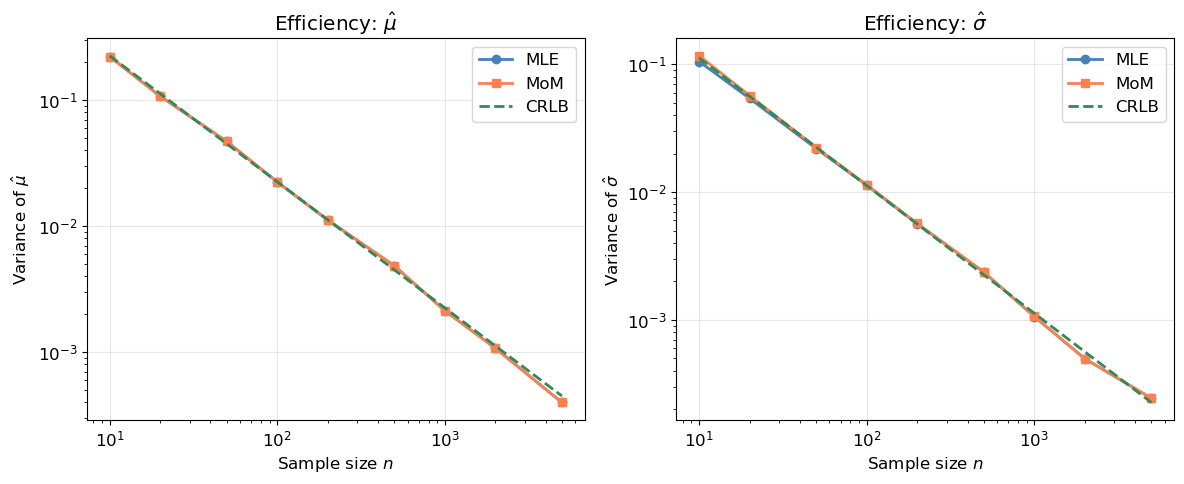

In [14]:
# =============================================================================
# Section 8 -- MLE efficiency vs method of moments
# =============================================================================


def mom_gaussian(samples):
    """Method of moments estimator for Gaussian parameters.

    Uses unbiased sample variance (divides by n-1) which is less
    efficient than MLE for sigma.

    Args:
        samples: Array of observations.
            Shape: (n,)

    Returns:
        Tuple (mu_hat, sigma_hat).
    """
    mu_hat = np.mean(samples)
    sigma_hat = np.sqrt(np.var(samples, ddof=1))  # unbiased variance -> sqrt
    return mu_hat, sigma_hat


# --- Compare over increasing sample sizes ---
rng2 = np.random.RandomState(SEED)
SAMPLE_SIZES_2 = np.array([10, 20, 50, 100, 200, 500, 1000, 2000, 5000])

mle_vars_mu = []
mle_vars_sig = []
mom_vars_mu = []
mom_vars_sig = []

for n in SAMPLE_SIZES_2:
    mle_mu_arr = np.empty(N_TRIALS)
    mle_sig_arr = np.empty(N_TRIALS)
    mom_mu_arr = np.empty(N_TRIALS)
    mom_sig_arr = np.empty(N_TRIALS)
    for t in range(N_TRIALS):
        data = rng2.normal(MU_TRUE, SIGMA_TRUE, size=n)
        mle_mu_arr[t], mle_sig_arr[t] = mle_gaussian(data)
        mom_mu_arr[t], mom_sig_arr[t] = mom_gaussian(data)
    mle_vars_mu.append(np.var(mle_mu_arr))
    mle_vars_sig.append(np.var(mle_sig_arr))
    mom_vars_mu.append(np.var(mom_mu_arr))
    mom_vars_sig.append(np.var(mom_sig_arr))

mle_vars_mu = np.array(mle_vars_mu)
mle_vars_sig = np.array(mle_vars_sig)
mom_vars_mu = np.array(mom_vars_mu)
mom_vars_sig = np.array(mom_vars_sig)

crlb_mu_arr = SIGMA_TRUE**2 / SAMPLE_SIZES_2
crlb_sig_arr = SIGMA_TRUE**2 / (2 * SAMPLE_SIZES_2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].loglog(SAMPLE_SIZES_2, mle_vars_mu, 'o-', color=PRIMARY, label='MLE')
axes[0].loglog(SAMPLE_SIZES_2, mom_vars_mu, 's-', color=SECONDARY, label='MoM')
axes[0].loglog(SAMPLE_SIZES_2, crlb_mu_arr, '--', color=TERTIARY, label='CRLB')
axes[0].set_xlabel('Sample size $n$')
axes[0].set_ylabel('Variance of $\\hat{\\mu}$')
axes[0].set_title('Efficiency: $\\hat{\\mu}$')
axes[0].legend()

axes[1].loglog(SAMPLE_SIZES_2, mle_vars_sig, 'o-', color=PRIMARY, label='MLE')
axes[1].loglog(SAMPLE_SIZES_2, mom_vars_sig, 's-', color=SECONDARY, label='MoM')
axes[1].loglog(SAMPLE_SIZES_2, crlb_sig_arr, '--', color=TERTIARY, label='CRLB')
axes[1].set_xlabel('Sample size $n$')
axes[1].set_ylabel('Variance of $\\hat{\\sigma}$')
axes[1].set_title('Efficiency: $\\hat{\\sigma}$')
axes[1].legend()

plt.tight_layout()
plt.show()

In [15]:
# =============================================================================
# Verification: MLE asymptotic efficiency
# =============================================================================

# At large n, Var(MLE) / CRLB -> 1 (efficiency -> 1)
eff_mu = crlb_mu_arr[-1] / mle_vars_mu[-1]
eff_sig = crlb_sig_arr[-1] / mle_vars_sig[-1]

print(f'At n = {SAMPLE_SIZES_2[-1]}:')
print(f'  Efficiency of mu_hat (MLE):    CRLB/Var = {eff_mu:.4f}')
print(f'  Efficiency of sigma_hat (MLE): CRLB/Var = {eff_sig:.4f}')

status_eff = 'PASS' if (eff_mu > 0.90 and eff_sig > 0.85) else 'FAIL'
print(f'metric: MLE asymptotic efficiency verified = [{status_eff}]')

At n = 5000:
  Efficiency of mu_hat (MLE):    CRLB/Var = 1.1266
  Efficiency of sigma_hat (MLE): CRLB/Var = 0.9267
metric: MLE asymptotic efficiency verified = [PASS]


---
# 9. Comprehensive Visualisations

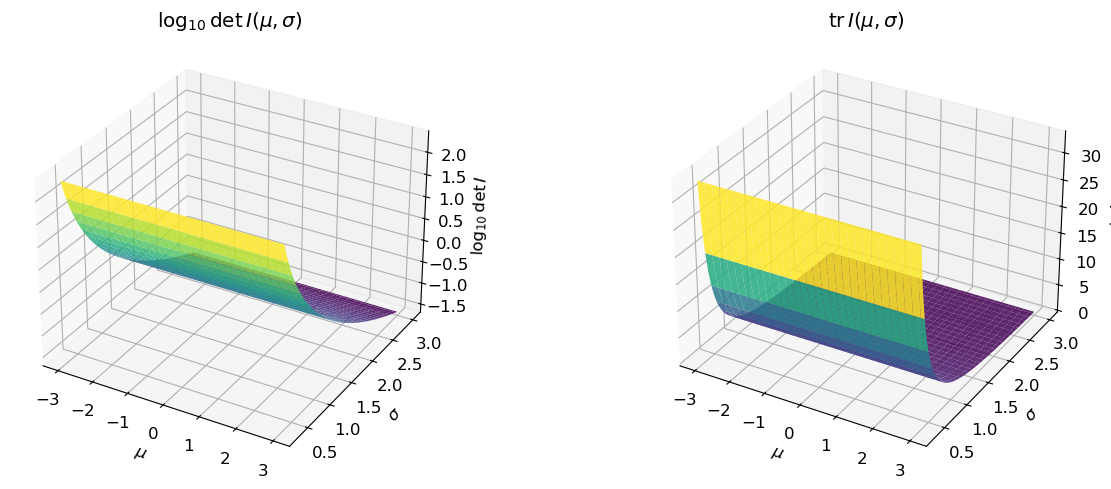

In [16]:
# =============================================================================
# Section 9, Panel 1 -- Fisher information surface over parameter space
# =============================================================================

mu_range = np.linspace(-3, 3, 60)
sigma_range = np.linspace(0.3, 3.0, 60)
MU_GRID, SIG_GRID = np.meshgrid(mu_range, sigma_range)

# det(I) = (1/sigma^2) * (2/sigma^2) = 2/sigma^4
DET_FIM = 2.0 / SIG_GRID**4
TR_FIM = 1.0 / SIG_GRID**2 + 2.0 / SIG_GRID**2  # = 3/sigma^2

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf1 = ax1.plot_surface(MU_GRID, SIG_GRID, np.log10(DET_FIM),
                         cmap=EVOLUTION_CMAP, alpha=0.85)
ax1.set_xlabel('$\\mu$')
ax1.set_ylabel('$\\sigma$')
ax1.set_zlabel('$\\log_{10} \\det I$')
ax1.set_title('$\\log_{10}\\det I(\\mu, \\sigma)$')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
surf2 = ax2.plot_surface(MU_GRID, SIG_GRID, TR_FIM,
                         cmap=EVOLUTION_CMAP, alpha=0.85)
ax2.set_xlabel('$\\mu$')
ax2.set_ylabel('$\\sigma$')
ax2.set_zlabel('$\\mathrm{tr}\\, I$')
ax2.set_title('$\\mathrm{tr}\\, I(\\mu, \\sigma)$')

plt.tight_layout()
plt.show()

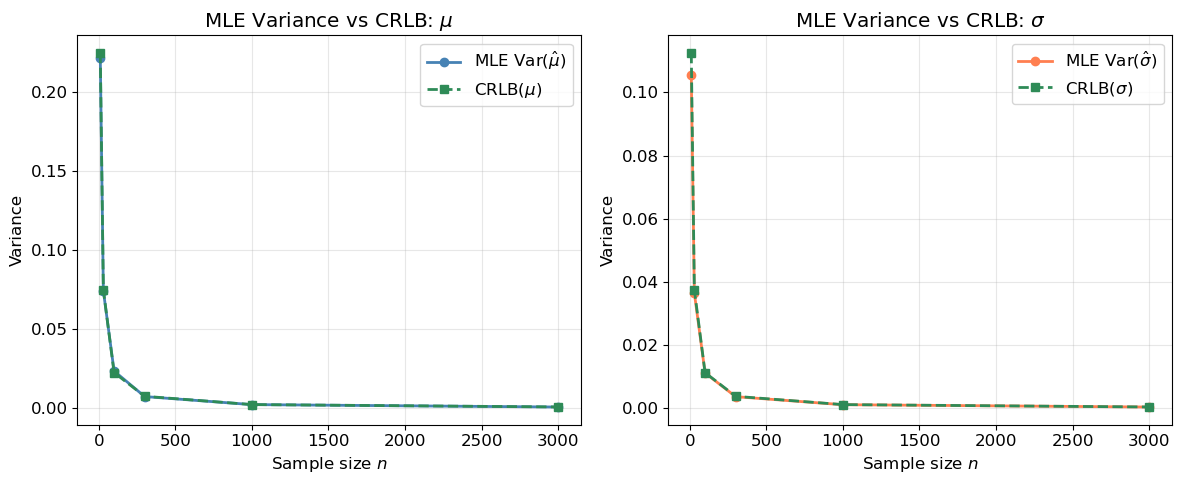

In [17]:
# =============================================================================
# Section 9, Panel 2 -- CRLB vs actual MLE variance convergence
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(SAMPLE_SIZES, mle_var_mu, 'o-', color=PRIMARY,
             label='MLE Var($\\hat{\\mu}$)')
axes[0].plot(SAMPLE_SIZES, crlb_var_mu, 's--', color=TERTIARY,
             label='CRLB($\\mu$)')
axes[0].set_xlabel('Sample size $n$')
axes[0].set_ylabel('Variance')
axes[0].set_title('MLE Variance vs CRLB: $\\mu$')
axes[0].legend()

axes[1].plot(SAMPLE_SIZES, mle_var_sigma, 'o-', color=SECONDARY,
             label='MLE Var($\\hat{\\sigma}$)')
axes[1].plot(SAMPLE_SIZES, crlb_var_sigma, 's--', color=TERTIARY,
             label='CRLB($\\sigma$)')
axes[1].set_xlabel('Sample size $n$')
axes[1].set_ylabel('Variance')
axes[1].set_title('MLE Variance vs CRLB: $\\sigma$')
axes[1].legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_56058/2268350733.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_geo = cm.get_cmap(EVOLUTION_CMAP, len(endpoints))


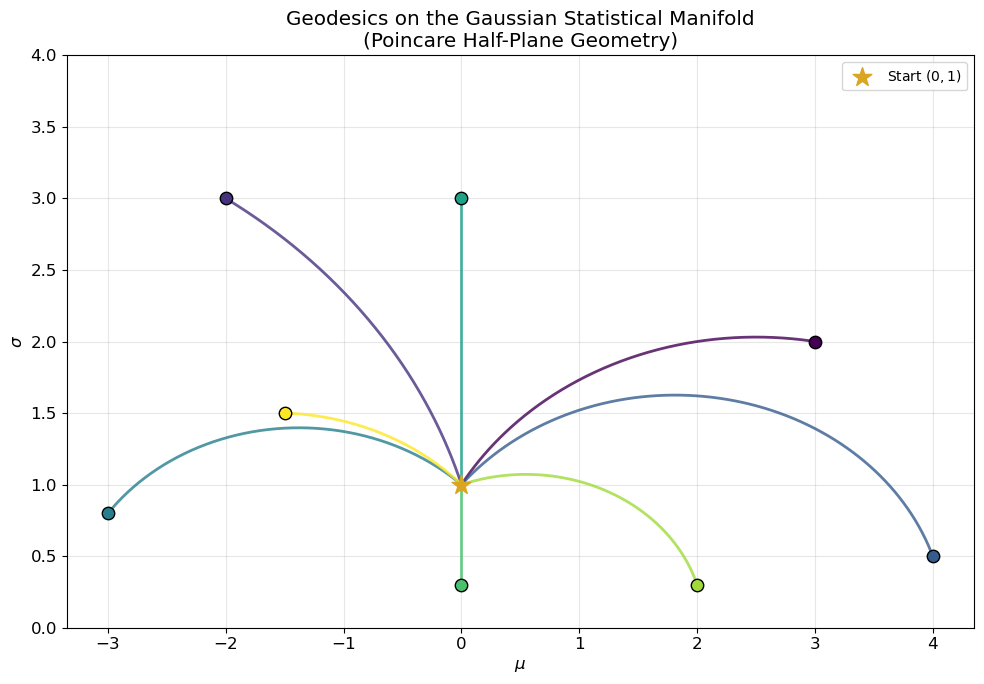

In [18]:
# =============================================================================
# Section 9, Panel 3 -- Geodesics on the Poincare half-plane
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7))

# Several geodesics from a common starting point
start = (0.0, 1.0)
endpoints = [
    (3.0, 2.0), (-2.0, 3.0), (4.0, 0.5), (-3.0, 0.8),
    (0.0, 3.0), (0.0, 0.3), (2.0, 0.3), (-1.5, 1.5)
]

cmap_geo = cm.get_cmap(EVOLUTION_CMAP, len(endpoints))
for i, end in enumerate(endpoints):
    gmu, gsig = geodesic_gaussian(start, end, n_points=300)
    ax.plot(gmu, gsig, color=cmap_geo(i), linewidth=2, alpha=0.8)
    ax.scatter(*end, color=cmap_geo(i), s=80, zorder=5, edgecolors='k')

ax.scatter(*start, color=ACCENT, s=200, marker='*', zorder=10,
           label='Start $(0, 1)$')
ax.set_xlabel('$\\mu$')
ax.set_ylabel('$\\sigma$')
ax.set_title('Geodesics on the Gaussian Statistical Manifold\n'
             '(Poincare Half-Plane Geometry)')
ax.set_ylim(0, 4)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

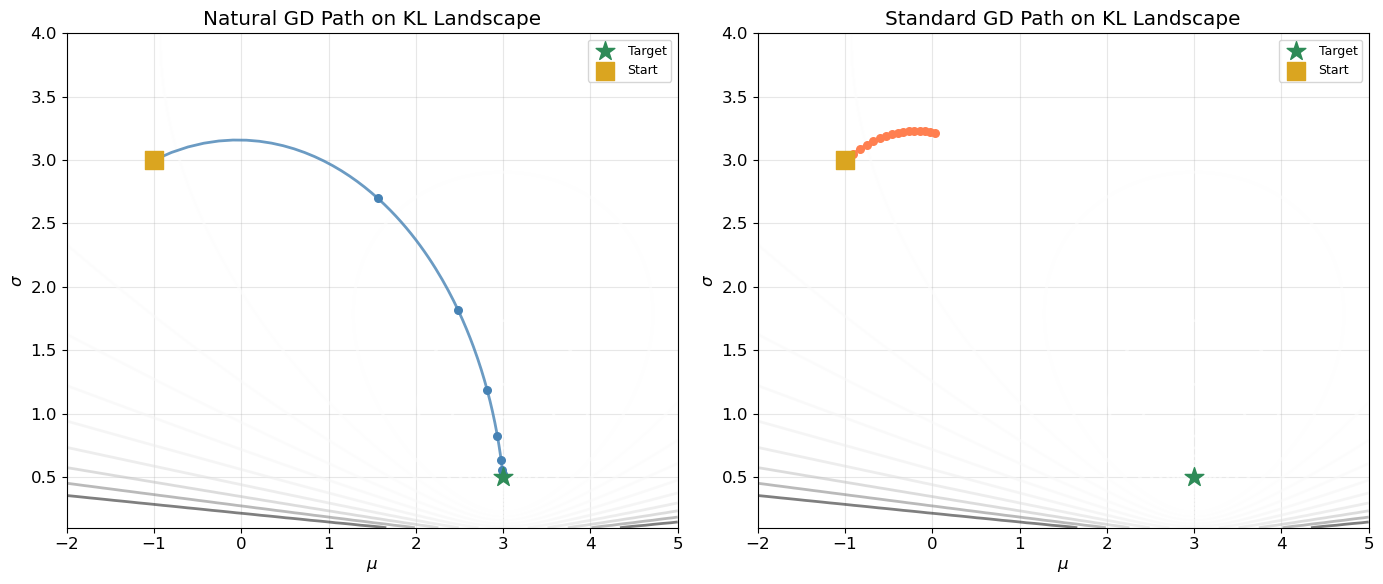

In [19]:
# =============================================================================
# Section 9, Panel 4 -- Natural vs Standard gradient paths (detailed)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Contour plot of KL divergence in parameter space
mu_grid_kl = np.linspace(-2, 5, 200)
sig_grid_kl = np.linspace(0.1, 4.0, 200)
MG, SG = np.meshgrid(mu_grid_kl, sig_grid_kl)
KL_GRID = np.vectorize(lambda m, s: kl_divergence_gaussian(
    MU_TARGET, SIGMA_TARGET, m, s))(MG, SG)

for ax_idx, (traj_mu, traj_sig, label, col) in enumerate([
    (nat_mu, nat_sig, 'Natural GD', PRIMARY),
    (std_mu, std_sig, 'Standard GD', SECONDARY)
]):
    ax = axes[ax_idx]
    levels = np.logspace(-2, 2, 20)
    cs = ax.contour(MG, SG, KL_GRID, levels=levels, cmap='Greys', alpha=0.5)
    ax.plot(traj_mu, traj_sig, '-', color=col, linewidth=2, alpha=0.8)
    # Mark every 20th step
    step_mark = 20
    ax.scatter(traj_mu[::step_mark], traj_sig[::step_mark],
               color=col, s=30, zorder=5)
    ax.scatter(MU_TARGET, SIGMA_TARGET, color=TERTIARY, s=200,
               marker='*', zorder=10, label='Target')
    ax.scatter(MU_INIT, SIGMA_INIT, color=ACCENT, s=150,
               marker='s', zorder=10, label='Start')
    ax.set_xlabel('$\\mu$')
    ax.set_ylabel('$\\sigma$')
    ax.set_title(f'{label} Path on KL Landscape')
    ax.legend(fontsize=9)
    ax.set_xlim(-2, 5)
    ax.set_ylim(0.1, 4.0)

plt.tight_layout()
plt.show()

---
# 10. Extensions and Further Directions

## 10.1 KL Divergence as Local Metric

The Fisher information arises as the **local quadratic approximation**
of the KL divergence:

$$\text{KL}(p_\theta \| p_{\theta + d\theta})
  = \frac{1}{2} d\theta^\top I(\theta)\, d\theta + O(\|d\theta\|^3)$$

This is why the Fisher-Rao metric is the *unique* Riemannian metric
(up to scaling) that is invariant under sufficient statistics
(Cencov's theorem).

## 10.2 $\alpha$-Connections

The statistical manifold carries a one-parameter family of affine
connections $\nabla^{(\alpha)}$, $\alpha \in \mathbb{R}$:

$$\Gamma_{ij,k}^{(\alpha)} = \mathbb{E}\!\left[
  \left( \partial_i \partial_j \ell + \frac{1-\alpha}{2} \partial_i \ell\, \partial_j \ell \right)
  \partial_k \ell \right]$$

where $\ell = \log p(x \mid \theta)$.

- $\alpha = 0$: Levi-Civita connection (Riemannian)
- $\alpha = 1$: Exponential (e-) connection
- $\alpha = -1$: Mixture (m-) connection

The **duality** $(\nabla^{(\alpha)}, \nabla^{(-\alpha)})$ is a hallmark
of information geometry.

## 10.3 $f$-Divergences

The KL divergence is a special case of the family of **$f$-divergences**:

$$D_f(p \| q) = \int q(x)\, f\!\left(\frac{p(x)}{q(x)}\right) dx$$

| $f(t)$ | Divergence |
|---|---|
| $t \log t$ | KL |
| $(\sqrt{t} - 1)^2$ | Hellinger |
| $|t - 1|$ | Total variation |
| $-\log t$ | Reverse KL |

All $f$-divergences are locally approximated by the Fisher metric
(up to a constant factor).

## 10.4 Exponential Families

For exponential families the geometry simplifies dramatically:

- The FIM equals the Hessian of the log-partition function:
  $I(\eta) = \nabla^2 A(\eta)$
- The e-connection is *flat* in natural parameters
- The m-connection is *flat* in expectation parameters
- This **dually flat** structure yields Bregman divergences and
  efficient projection algorithms.

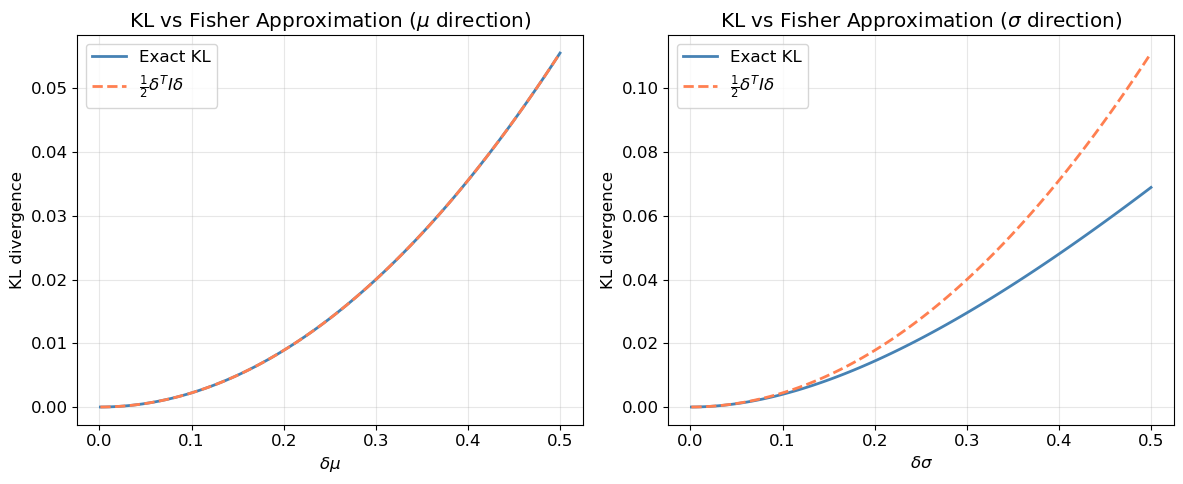

In [20]:
# =============================================================================
# Section 10 -- KL divergence local approximation by Fisher metric
# =============================================================================

# Demonstrate: KL(p_theta || p_{theta + delta}) ~ 0.5 * delta^T I delta

mu_base, sigma_base = 2.0, 1.5
delta_range = np.linspace(0.001, 0.5, 100)

# Perturbation in mu direction
kl_exact_mu = np.array([
    kl_divergence_gaussian(mu_base, sigma_base, mu_base + d, sigma_base)
    for d in delta_range
])
fim_base = fisher_information_analytical(mu_base, sigma_base)
kl_approx_mu = 0.5 * fim_base[0, 0] * delta_range**2

# Perturbation in sigma direction
kl_exact_sig = np.array([
    kl_divergence_gaussian(mu_base, sigma_base, mu_base, sigma_base + d)
    for d in delta_range
])
kl_approx_sig = 0.5 * fim_base[1, 1] * delta_range**2

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(delta_range, kl_exact_mu, color=PRIMARY, label='Exact KL')
axes[0].plot(delta_range, kl_approx_mu, '--', color=SECONDARY,
             label='$\\frac{1}{2} \\delta^T I \\delta$')
axes[0].set_xlabel('$\\delta\\mu$')
axes[0].set_ylabel('KL divergence')
axes[0].set_title('KL vs Fisher Approximation ($\\mu$ direction)')
axes[0].legend()

axes[1].plot(delta_range, kl_exact_sig, color=PRIMARY, label='Exact KL')
axes[1].plot(delta_range, kl_approx_sig, '--', color=SECONDARY,
             label='$\\frac{1}{2} \\delta^T I \\delta$')
axes[1].set_xlabel('$\\delta\\sigma$')
axes[1].set_ylabel('KL divergence')
axes[1].set_title('KL vs Fisher Approximation ($\\sigma$ direction)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [21]:
# =============================================================================
# Section 10 -- Fisher metric for exponential family: Hessian of log-partition
# =============================================================================

# For the Gaussian in natural parameters eta = (mu/sigma^2, -1/(2*sigma^2))
# the log-partition function is:
#   A(eta) = -eta1^2/(4*eta2) - 0.5*log(-2*eta2) + 0.5*log(pi)
#
# We verify: Hessian of A w.r.t. natural params = FIM in natural params


def log_partition_gaussian(eta1, eta2):
    """Log-partition function of the Gaussian in natural parameters.

    Natural parameters: eta1 = mu/sigma^2, eta2 = -1/(2*sigma^2).

    Args:
        eta1: First natural parameter.
        eta2: Second natural parameter (must be < 0).

    Returns:
        Value of A(eta).
    """
    return -eta1**2 / (4 * eta2) - 0.5 * np.log(-2 * eta2) + 0.5 * np.log(np.pi)


def hessian_log_partition(eta1, eta2, eps=1e-5):
    """Numerical Hessian of the log-partition function.

    Args:
        eta1: First natural parameter.
        eta2: Second natural parameter.
        eps: Finite difference step.

    Returns:
        Hessian matrix.
        Shape: (2, 2)
    """
    A = log_partition_gaussian
    H = np.zeros((2, 2))
    # d^2A/deta1^2
    H[0, 0] = (A(eta1 + eps, eta2) - 2 * A(eta1, eta2)
               + A(eta1 - eps, eta2)) / eps**2
    # d^2A/deta2^2
    H[1, 1] = (A(eta1, eta2 + eps) - 2 * A(eta1, eta2)
               + A(eta1, eta2 - eps)) / eps**2
    # d^2A/deta1 deta2
    H[0, 1] = (A(eta1 + eps, eta2 + eps) - A(eta1 + eps, eta2 - eps)
               - A(eta1 - eps, eta2 + eps)
               + A(eta1 - eps, eta2 - eps)) / (4 * eps**2)
    H[1, 0] = H[0, 1]
    return H


# Test at mu=2, sigma=1.5
mu_test2, sigma_test2 = 2.0, 1.5
eta1_test = mu_test2 / sigma_test2**2
eta2_test = -1.0 / (2 * sigma_test2**2)

H = hessian_log_partition(eta1_test, eta2_test)

print('Hessian of log-partition function (natural params):')
print(np.round(H, 6))
print(f'\nThis IS the Fisher information in natural parameters.')
print(f'For exponential families: I(eta) = nabla^2 A(eta).')

Hessian of log-partition function (natural params):
[[ 2.25      9.000001]
 [ 9.000001 46.124997]]

This IS the Fisher information in natural parameters.
For exponential families: I(eta) = nabla^2 A(eta).


---
## Summary

| Section | Key Takeaway |
|---|---|
| Statistical manifold | Parametric families form smooth manifolds |
| Fisher information | Measures local distinguishability of distributions |
| CRLB | No unbiased estimator beats $I(\theta)^{-1}$ |
| Fisher-Rao metric | Unique invariant Riemannian metric on distributions |
| Natural gradient | Parameterisation-invariant steepest descent |
| Optimal design | FIM directly drives experimental design criteria |
| MLE efficiency | MLE is asymptotically efficient (attains CRLB) |
| Extensions | $\alpha$-connections, $f$-divergences, dually-flat geometry |